In [9]:
# ============================================================
# CELL 1
# VQA DATASET
# ============================================================

import sys
from pathlib import Path
from io import BytesIO

import matplotlib.pyplot as plt
from PIL import Image


# ============================================================
# 1. Project root
# ============================================================

ROOT = Path("/home/lizhihao/phd/VRGA")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


# ============================================================
# 2. Import dataset
# ============================================================

from vqa_datasets.evalDataset import EvalDataset


# ============================================================
# 3. Dataset name
# ============================================================

DATASET_NAME = "HallusionBench"


# ============================================================
# 4. Load dataset
# ============================================================

dataset = EvalDataset(
    data_name=DATASET_NAME
)

data = dataset.get_data()


print("=" * 70)
print("Dataset:", DATASET_NAME)
print("Number of samples:", len(data))
print("=" * 70)

Dataset: HallusionBench
Number of samples: 951


In [10]:
# ============================================================
# CELL 2
# IMAGE PROCESSING
# ============================================================

def load_image(image):
    """
    Convert different image formats to PIL.Image.Image.
    """

    # --------------------------------------------------------
    # PIL Image
    # --------------------------------------------------------

    if isinstance(image, Image.Image):

        return image.convert("RGB")


    # --------------------------------------------------------
    # Image path
    # --------------------------------------------------------

    elif isinstance(image, str):

        return Image.open(
            image
        ).convert("RGB")


    # --------------------------------------------------------
    # Bytes
    # --------------------------------------------------------

    elif isinstance(image, bytes):

        return Image.open(
            BytesIO(image)
        ).convert("RGB")


    # --------------------------------------------------------
    # HuggingFace Image dictionary
    # --------------------------------------------------------

    elif isinstance(image, dict):

        # Image stored as bytes
        if image.get("bytes") is not None:

            return Image.open(
                BytesIO(image["bytes"])
            ).convert("RGB")


        # Image stored as path
        elif image.get("path") is not None:

            return Image.open(
                image["path"]
            ).convert("RGB")


        else:

            raise ValueError(
                f"Unknown image dictionary: {image.keys()}"
            )


    # --------------------------------------------------------
    # Unsupported type
    # --------------------------------------------------------

    else:

        raise TypeError(
            f"Unsupported image type: {type(image)}"
        )

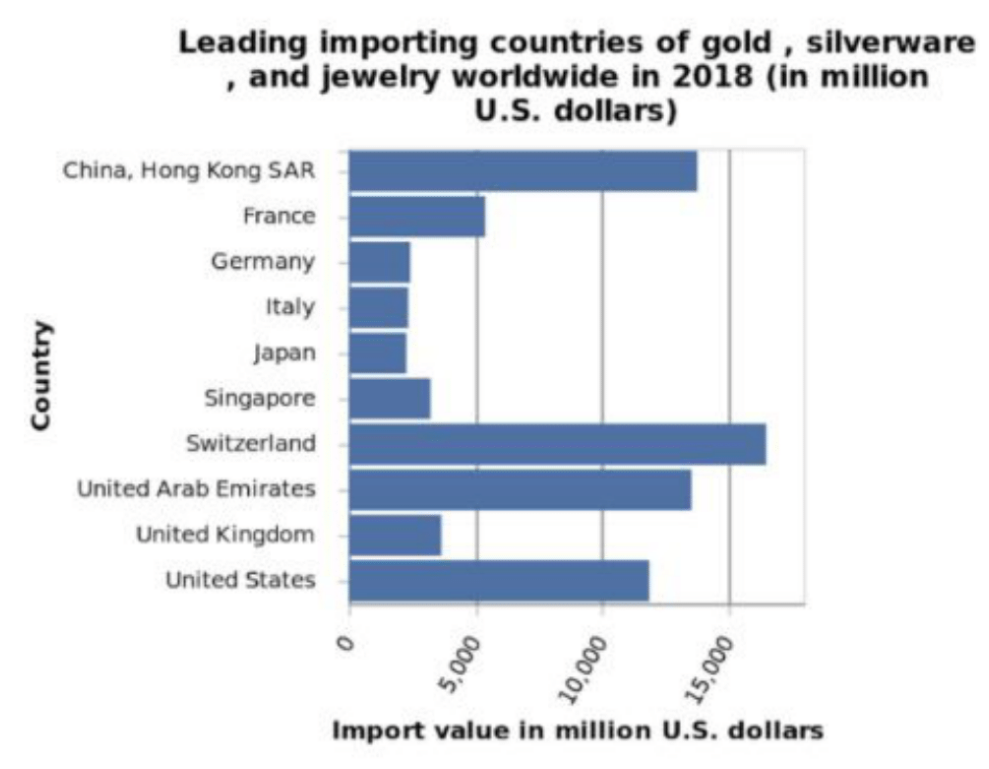

ID:
0

Type:
VS_chart

Question:
Is China, Hongkong SAR, the leading importing country of gold, silverware, and jewelry with the highest import value in 2018?

Ground Truth:
Switzerland is the leading importing country of gold, silverware, and jewelry with the highest import value in 2018?


In [11]:
# ============================================================
# CELL 3
# GET ONE VQA SAMPLE
# ============================================================

def get_sample(data, index=0):

    sample = data[index]

    # --------------------------------------------------------
    # Image
    # --------------------------------------------------------

    image = load_image(
        sample["image"]
    )

    # --------------------------------------------------------
    # Question
    # --------------------------------------------------------

    question = sample["question"]

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    answer = sample.get(
        "answer",
        None
    )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    sample_id = sample.get(
        "id",
        None
    )

    sample_type = sample.get(
        "type",
        None
    )

    return {
        "image": image,
        "question": question,
        "answer": answer,
        "id": sample_id,
        "type": sample_type,
    }


# ============================================================
# Select sample
# ============================================================

sample_index = 0

sample = get_sample(
    data,
    index=sample_index
)


# ============================================================
# Extract
# ============================================================

image = sample["image"]

question = sample["question"]

ground_truth = sample["answer"]


# ============================================================
# Display image
# ============================================================

plt.figure(
    figsize=(10, 8)
)

plt.imshow(image)

plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================
# Display information
# ============================================================

print("=" * 70)

print("ID:")
print(sample["id"])

print("\nType:")
print(sample["type"])

print("\nQuestion:")
print(question)

print("\nGround Truth:")
print(ground_truth)

print("=" * 70)

In [30]:
from origin.load_qwn_model import load_qwen_model

model, processor = load_qwen_model()

Loading Qwen2.5-VL-3B-Instruct...


Loading weights: 100%|██████████| 824/824 [00:02<00:00, 326.31it/s]


Model loaded.


In [31]:
# ============================================================
# QWEN VQA INFERENCE
# ============================================================

def qwen_vqa(
    model,
    processor,
    image,
    question,
    prompt,
    max_new_tokens=512,
):

    # ========================================================
    # 1. Build conversation
    # ========================================================

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": (
                        f"{prompt}\n\n"
                        f"Question: {question}\n\n"
                        "Answer:"
                    ),
                },
            ],
        }
    ]


    # ========================================================
    # 2. Apply chat template
    # ========================================================

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


    # ========================================================
    # 3. Process image + text
    # ========================================================

    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )


    # ========================================================
    # 4. Move to GPU
    # ========================================================

    inputs = {
        key: value.to(model.device)
        if torch.is_tensor(value)
        else value
        for key, value in inputs.items()
    }


    # ========================================================
    # 5. Generate
    # ========================================================

    with torch.inference_mode():

        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )


    # ========================================================
    # 6. Remove input tokens
    # ========================================================

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]


    # ========================================================
    # 7. Decode
    # ========================================================

    response = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]


    return response

In [32]:
ORI_PROMPT = """
Answer the question based on the image.
Think step by step.
The final answer MUST BE in <answer> </answer> tags.
"""
response = qwen_vqa(
    model=model,
    processor=processor,
    image=image,
    question=question,
    prompt=ORI_PROMPT,
    max_new_tokens=2000,
)

print(response)

To determine if China, Hong Kong SAR is the leading importing country of gold, silverware, and jewelry with the highest import value in 2018, we need to compare the import values for each country listed in the bar graph.

Here are the steps to analyze the data:

1. Identify the import values for each country:
   - China, Hong Kong SAR: Approximately $15,000 million
   - France: Approximately $6,000 million
   - Germany: Approximately $4,000 million
   - Italy: Approximately $3,000 million
   - Japan: Approximately $2,000 million
   - Singapore: Approximately $2,000 million
   - Switzerland: Approximately $17,000 million
   - United Arab Emirates: Approximately $14,000 million
   - United Kingdom: Approximately $5,000 million
   - United States: Approximately $12,000 million

2. Compare these values to find the highest:
   - The highest value among these countries is approximately $17,000 million (Switzerland).

3. Determine if China, Hong Kong SAR has the highest value:
   - China, Hon